## PARTE 1: Preparación del dataset y entrenamiento de YOLOv8n-cls

Montaje de Google Drive, copia del dataset, división estratificada 70/20/10 y entrenamiento del modelo principal (YOLOv8n-cls, 50 épocas).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
from pathlib import Path

origen_drive = Path("/content/drive/MyDrive/Calabaza")
origen_local = Path("/content/hoja_calabaza")

shutil.copytree(origen_drive, origen_local)

print("Dataset copiado a disco local.")

Dataset copiado a disco local.


In [3]:
from pathlib import Path

ruta = Path("/content/drive/MyDrive/Calabaza")

print("Existe:", ruta.exists())
print("Contenido:")
for item in ruta.iterdir():
    print("-", item.name)

Existe: True
Contenido:
- Healthy Leaf
- Downy Mildew
- Powdery_Mildew
- Bacterial Leaf Spot
- Mosaic Disease


In [4]:
from pathlib import Path

origen_drive = Path("/content/drive/MyDrive/Calabaza")

extensiones = [".jpg", ".jpeg", ".png", ".webp", ".JPG", ".JPEG", ".PNG", ".WEBP"]

for clase_dir in origen_drive.iterdir():
    if clase_dir.is_dir():
        imagenes = []
        for ext in extensiones:
            imagenes.extend(list(clase_dir.rglob(f"*{ext}")))
        print(clase_dir.name, ":", len(imagenes))

Healthy Leaf : 400
Downy Mildew : 400
Powdery_Mildew : 400
Bacterial Leaf Spot : 400
Mosaic Disease : 400


In [5]:
import random
import shutil
from pathlib import Path

origen = Path("/content/drive/MyDrive/Calabaza")
destino = Path("/content/hoja_calabaza")

# Borra una división anterior si existía
if destino.exists():
    shutil.rmtree(destino)

random.seed(42)

train_ratio = 0.70
val_ratio = 0.20

extensiones = [".jpg", ".jpeg", ".png", ".webp", ".JPG", ".JPEG", ".PNG", ".WEBP"]

def limpiar_nombre(nombre):
    return nombre.strip().replace(" ", "_")

for clase_dir in origen.iterdir():
    if not clase_dir.is_dir():
        continue

    clase = limpiar_nombre(clase_dir.name)

    imagenes = []
    for ext in extensiones:
        imagenes.extend(list(clase_dir.rglob(f"*{ext}")))

    random.shuffle(imagenes)

    total = len(imagenes)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    splits = {
        "train": imagenes[:train_end],
        "val": imagenes[train_end:val_end],
        "test": imagenes[val_end:]
    }

    for split, files in splits.items():
        carpeta_destino = destino / split / clase
        carpeta_destino.mkdir(parents=True, exist_ok=True)

        for i, img in enumerate(files):
            nuevo_nombre = f"{clase}_{i}{img.suffix.lower()}"
            shutil.copy(img, carpeta_destino / nuevo_nombre)

print("Dataset dividido correctamente en train, val y test.")

Dataset dividido correctamente en train, val y test.


In [6]:
from pathlib import Path

base = Path("/content/hoja_calabaza")

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for clase_dir in sorted((base / split).iterdir()):
        if clase_dir.is_dir():
            cantidad = len(list(clase_dir.glob("*")))
            print(f"{clase_dir.name}: {cantidad}")


TRAIN
Bacterial_Leaf_Spot: 280
Downy_Mildew: 280
Healthy_Leaf: 280
Mosaic_Disease: 280
Powdery_Mildew: 280

VAL
Bacterial_Leaf_Spot: 80
Downy_Mildew: 80
Healthy_Leaf: 80
Mosaic_Disease: 80
Powdery_Mildew: 80

TEST
Bacterial_Leaf_Spot: 40
Downy_Mildew: 40
Healthy_Leaf: 40
Mosaic_Disease: 40
Powdery_Mildew: 40


In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data="/content/hoja_calabaza",
    epochs=50,
    imgsz=224,
    batch=16,
    name="calabaza_yolov8n_cls_v1",
    plots=True
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hoja_calabaza, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d172a2e47a0>
curves: []
curves_results: []
fitness: 0.9474999904632568
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8949999809265137, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9474999904632568}
save_dir: PosixPath('/content/runs/classify/calabaza_yolov8n_cls_v1')
speed: {'preprocess': 0.1231889299992872, 'inference': 0.4074463224998226, 'loss': 0.0003236074996948446, 'postprocess': 0.0004729100004396969}
top1: 0.8949999809265137
top5: 1.0

### Corrida adicional: 100 épocas (experimento independiente)

Mismo modelo base (YOLOv8n-cls) y mismo dataset, entrenado por más tiempo para evaluar si el desempeño mejora. Resultado: Accuracy Top-1 de 0.88 (mejor época: 22), frente a 0.895 de la corrida de 50 épocas — sin mejora.

In [14]:
!pip install ultralytics -q


from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data="/content/hoja_calabaza",
    epochs=100,
    imgsz=224,
    batch=32,
    name="calabaza_yolov8n_cls_100ep",
    plots=True
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hoja_calabaza, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab43e8d2840>
curves: []
curves_results: []
fitness: 0.9399999976158142
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8799999952316284, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9399999976158142}
save_dir: PosixPath('/content/runs/classify/calabaza_yolov8n_cls_100ep')
speed: {'preprocess': 0.08496660249988963, 'inference': 0.4201950775006935, 'loss': 0.0031150275003710703, 'postprocess': 0.00035633250035971287}
top1: 0.8799999952316284
top5: 1.0

In [ ]:
import shutil
from pathlib import Path

# Rutas origen
hoja_calabaza = Path("/content/hoja_calabaza")
runs = Path("/content/runs")

# Ruta destino en Drive
destino_drive = Path("/content/drive/MyDrive/Calabaza_Backup")
destino_drive.mkdir(parents=True, exist_ok=True)

# Comprimir hoja_calabaza
shutil.make_archive(
    base_name=str(destino_drive / "hoja_calabaza"),
    format="zip",
    root_dir=hoja_calabaza
)

# Comprimir runs
shutil.make_archive(
    base_name=str(destino_drive / "runs"),
    format="zip",
    root_dir=runs
)

print("Listo, ambos zips guardados en:", destino_drive)

Listo, ambos zips guardados en: /content/drive/MyDrive/Calabaza_Backup


## PARTE 2: Entrenamiento de MobileNetV2 (transfer learning)

Fase 1 (extracción de características) y Fase 2 (fine-tuning de las últimas 50 capas), evaluado sobre el conjunto de prueba.

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path

# Ruta en Colab (ya la tienes local, si la subiste a Drive ajusta el path)
DATASET_PATH = Path("/content/hoja_calabaza")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15

# Cargar train, val y test por separado (ya vienen divididos)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "train",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "val",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "test",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Clases detectadas:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Aumentación de datos
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Modelo base MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Evaluación final en TEST (esta es la métrica que reportas en el paper)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

# Guardar modelo
model.save("/content/modelo_calabaza.keras")

# Guardar nombres de clases
with open("/content/clases.txt", "w", encoding="utf-8") as f:
    for clase in class_names:
        f.write(clase + "\n")

print("Modelo guardado como modelo_calabaza.keras")
print("Clases guardadas en clases.txt")

Found 1400 files belonging to 5 classes.
Found 400 files belonging to 5 classes.
Found 200 files belonging to 5 classes.
Clases detectadas: ['Bacterial_Leaf_Spot', 'Downy_Mildew', 'Healthy_Leaf', 'Mosaic_Disease', 'Powdery_Mildew']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.4936 - loss: 1.2451 - val_accuracy: 0.6650 - val_loss: 0.9350
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.6864 - loss: 0.8457 - val_accuracy: 0.7175 - val_loss: 0.7614
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.7043 - loss: 0.7610 - val_accuracy: 0.6825 - val_loss: 0.8023
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.7543 - loss: 0.6908 - val_accuracy: 0.7475 - val_loss: 0.6875
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.7593 - loss: 0.6589 - val_accuracy: 0.7000 - val_loss: 0.7642
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.7736 - loss: 0.6267 - val_accuracy: 0.7275 - val_loss: 0.7025
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.7686 - loss: 0.6321 - val_accuracy: 0.7375 - val_loss: 0.7036
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.7950 - loss: 0.5631 - val_accuracy:

In [9]:
# FASE 1: ya la hiciste (base congelada, entrena solo la cabeza)
# ... (tu código actual)

# FASE 2: fine-tuning — descongela las últimas capas de MobileNetV2
base_model.trainable = True

# Congela todas menos las últimas ~30 capas
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompila con learning rate MUY bajo (importante, si no destruyes los pesos preentrenados)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Continúa entrenando desde donde quedó
fine_tune_epochs = 15
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    callbacks=callbacks
)

# Vuelve a evaluar en test
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy después de fine-tuning: {test_acc:.4f}")

model.save("/content/modelo_calabaza_finetuned.keras")

Epoch 13/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 190ms/step - accuracy: 0.4114 - loss: 1.9752 - val_accuracy: 0.7075 - val_loss: 0.7155
Epoch 14/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.5686 - loss: 1.3019 - val_accuracy: 0.6975 - val_loss: 0.8410
Epoch 15/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy: 0.6986 - loss: 0.8487 - val_accuracy: 0.6625 - val_loss: 0.8890
Epoch 16/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.7507 - loss: 0.7023 - val_accuracy: 0.6700 - val_loss: 0.8649
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.7400 - loss: 0.6926
Test accuracy después de fine-tuning: 0.7400


                     precision    recall  f1-score   support

Bacterial_Leaf_Spot       0.60      0.82      0.69        40
       Downy_Mildew       0.72      0.85      0.78        40
       Healthy_Leaf       0.84      0.65      0.73        40
     Mosaic_Disease       1.00      0.70      0.82        40
     Powdery_Mildew       0.69      0.68      0.68        40

           accuracy                           0.74       200
          macro avg       0.77      0.74      0.74       200
       weighted avg       0.77      0.74      0.74       200



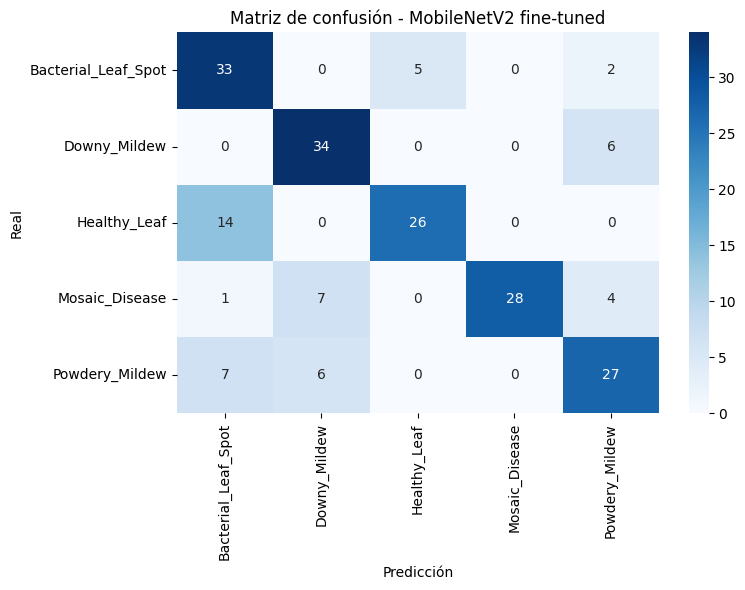

In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones sobre test_ds
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Reporte por clase
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - MobileNetV2 fine-tuned")
plt.tight_layout()
plt.savefig("/content/confusion_matrix_mobilenet.png", dpi=150)
plt.show()

In [11]:
# FASE 2: Fine-tuning con callback corregido

base_model.trainable = True

# Descongela más capas esta vez (últimas 50 en vez de 30)
fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Capas entrenables: {sum(l.trainable for l in base_model.layers)} de {len(base_model.layers)}")

# Recompila con learning rate bajo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback separado, con más paciencia solo para esta fase
callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )
]

fine_tune_epochs = 20  # le damos más margen para que realmente converja

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=callbacks_finetune
)

# Evaluación final en TEST
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy después de fine-tuning (v2): {test_acc:.4f}")

model.save("/content/modelo_calabaza_finetuned_v2.keras")

Capas entrenables: 30 de 154
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.5607 - loss: 1.2634 - val_accuracy: 0.6825 - val_loss: 0.8589
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.6964 - loss: 0.8747 - val_accuracy: 0.6500 - val_loss: 0.9343
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.7586 - loss: 0.6798 - val_accuracy: 0.6600 - val_loss: 0.9092
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.7564 - loss: 0.6433 - val_accuracy: 0.6875 - val_loss: 0.8512
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.7864 - loss: 0.5828 - val_accuracy: 0.7100 - val_loss: 0.7916
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.7957 - loss: 0.5500 - val_accuracy: 0.7375 - val_loss: 0.7258
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.7943 - loss: 0.5548 - val_accuracy: 0.7725 - val_loss: 0.6697
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.8000 - 

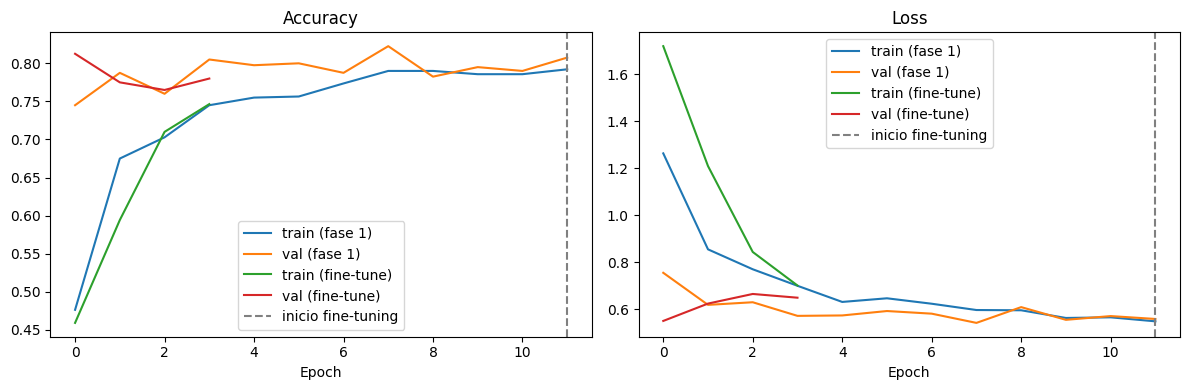

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train (fase 1)')
plt.plot(history.history['val_accuracy'], label='val (fase 1)')
plt.plot(history_fine.history['accuracy'], label='train (fine-tune)')
plt.plot(history_fine.history['val_accuracy'], label='val (fine-tune)')
plt.axvline(x=len(history.history['accuracy'])-1, color='gray', linestyle='--', label='inicio fine-tuning')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train (fase 1)')
plt.plot(history.history['val_loss'], label='val (fase 1)')
plt.plot(history_fine.history['loss'], label='train (fine-tune)')
plt.plot(history_fine.history['val_loss'], label='val (fine-tune)')
plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle='--', label='inicio fine-tuning')
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.savefig("/content/curvas_entrenamiento.png", dpi=150)
plt.show()

                     precision    recall  f1-score   support

Bacterial_Leaf_Spot       0.70      0.80      0.74        40
       Downy_Mildew       0.74      0.93      0.82        40
       Healthy_Leaf       0.84      0.78      0.81        40
     Mosaic_Disease       0.91      0.80      0.85        40
     Powdery_Mildew       0.91      0.72      0.81        40

           accuracy                           0.81       200
          macro avg       0.82      0.80      0.81       200
       weighted avg       0.82      0.81      0.81       200



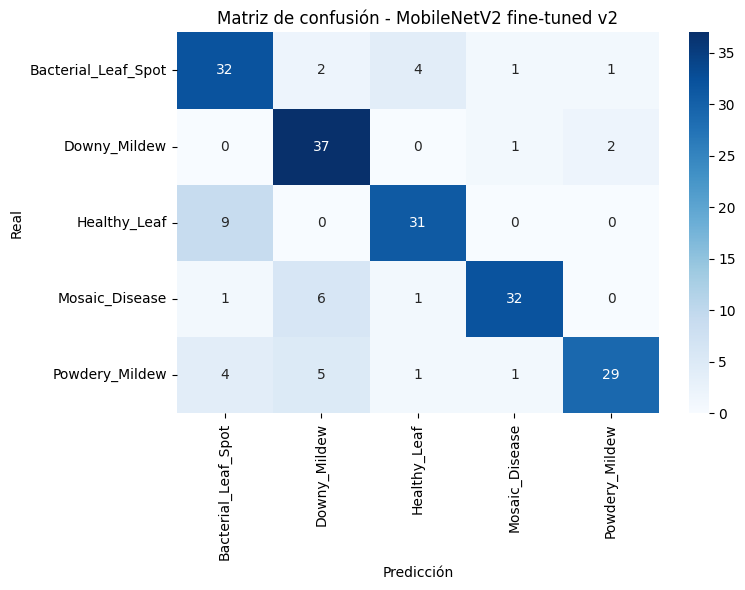

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - MobileNetV2 fine-tuned v2")
plt.tight_layout()
plt.savefig("/content/confusion_matrix_mobilenet_v2.png", dpi=150)
plt.show()

## PARTE 3: Entrenamiento de EfficientNetB0 (transfer learning)

Se evalúan dos estrategias: extracción de características y ajuste fino, usando el mismo `train_ds`/`val_ds`/`test_ds` cargados en la Parte 2.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15

# Reutiliza train_ds, val_ds, test_ds que ya tienes cargados

# Aumentación de datos (misma que antes)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ============ FASE 1: Feature extraction ============
base_model_eff = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model_eff.trainable = False

model_eff = models.Sequential([
    data_augmentation,
    layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

model_eff.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_eff.summary()

callbacks_fase1 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history_eff = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_fase1
)

test_loss, test_acc = model_eff.evaluate(test_ds)
print(f"Test accuracy EfficientNetB0 (fase 1): {test_acc:.4f}")

# ============ FASE 2: Fine-tuning ============
base_model_eff.trainable = True

fine_tune_at = len(base_model_eff.layers) - 50
for layer in base_model_eff.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Capas entrenables: {sum(l.trainable for l in base_model_eff.layers)} de {len(base_model_eff.layers)}")

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
]

fine_tune_epochs = 20

history_eff_fine = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=callbacks_finetune
)

test_loss, test_acc = model_eff.evaluate(test_ds)
print(f"Test accuracy EfficientNetB0 (fine-tuned): {test_acc:.4f}")

model_eff.save("/content/modelo_efficientnet_finetuned.keras")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 195ms/step - accuracy: 0.4750 - loss: 1.2887 - val_accuracy: 0.6450 - val_loss: 0.9711
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.6693 - loss: 0.9046 - val_accuracy: 0.7450 - val_loss: 0.7849
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.7129 - loss: 0.7927 - val_accuracy: 0.7850 - val_loss: 0.6975
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.7436 - loss: 0.7179 - val_accuracy: 0.7975 - val_loss: 0.6512
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.7336 - loss: 0.7070 - val_accuracy: 0.8150 - val_loss: 0.6152
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.7514 - loss: 0.6714 - val_accuracy: 0.8125 - val_loss: 0.5976
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step - accuracy: 0.7686 - loss: 0.6301 - val_accuracy: 0.8125 - val_loss: 0.5677
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.7693 - loss: 0.6220 - val_accuracy:

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model_eff = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model_eff.trainable = False

model_eff_final = models.Sequential([
    data_augmentation,
    layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

model_eff_final.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_fase1 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history_eff_final = model_eff_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_fase1
)

test_loss, test_acc = model_eff_final.evaluate(test_ds)
print(f"Test accuracy EfficientNetB0 (fase 1, versión final): {test_acc:.4f}")

# Guarda AQUÍ, antes de cualquier fine-tuning
model_eff_final.save("/content/modelo_efficientnet_fase1.keras")

with open("/content/clases.txt", "w", encoding="utf-8") as f:
    for clase in class_names:
        f.write(clase + "\n")

print("Modelo guardado: modelo_efficientnet_fase1.keras")

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.4864 - loss: 1.2869 - val_accuracy: 0.6750 - val_loss: 0.9703
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.6786 - loss: 0.9076 - val_accuracy: 0.6925 - val_loss: 0.8006
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.7207 - loss: 0.7832 - val_accuracy: 0.7600 - val_loss: 0.7164
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.7200 - loss: 0.7357 - val_accuracy: 0.7675 - val_loss: 0.6600
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.7500 - loss: 0.6777 - val_accuracy: 0.8000 - val_loss: 0.6237
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.7629 - loss: 0.6524 - val_accuracy: 0.7925 - val_loss: 0.5975
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.7907 - loss: 0.6174 - val_accuracy: 0.8000 - val_loss: 0.5690
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.7771 - loss: 0.6216 - val_accuracy: 